<a href="https://colab.research.google.com/github/talktoarusharya/Cat_vs_dog/blob/main/Cat_vs_Dog_classifier_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
from google.colab import files
files.upload()

Saving kaggle (1).json to kaggle (1).json


{'kaggle (1).json': b'{"username":"arusharya345","key":"f2889e928e332e043f51a477faee74ce"}'}

In [10]:
!mv "kaggle (1).json" kaggle.json

In [11]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [12]:
!kaggle datasets list -s dogs-vs-cats

ref                                                    title                                                size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------  ---------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
shaunthesheep/microsoft-catsvsdogs-dataset             Cats-vs-Dogs                                    825979578  2020-03-12 05:34:30.730000         107332        969  0.875            
biaiscience/dogs-vs-cats                               Dogs vs Cats                                    856265363  2017-12-05 14:03:33.210000          31476        364  0.4375           
pybear/cats-vs-dogs                                    Cats -- VS -- Dogs                              825979578  2020-10-18 13:55:30.950000           3295        105  0.625            
sujaykapadnis/cats-vs-dogs                             Cats Vs Dogs   

In [13]:
!kaggle datasets download -d salader/dogsvscats

Dataset URL: https://www.kaggle.com/datasets/salader/dogsvscats
License(s): unknown
dogsvscats.zip: Skipping, found more recently modified local copy (use --force to force download)


In [14]:
!unzip dogsvscats.zip

Streaming output truncated to the last 5000 lines.
  inflating: train/dogs/dog.4419.jpg  
  inflating: train/dogs/dog.442.jpg  
  inflating: train/dogs/dog.4420.jpg  
  inflating: train/dogs/dog.4421.jpg  
  inflating: train/dogs/dog.4422.jpg  
  inflating: train/dogs/dog.4424.jpg  
  inflating: train/dogs/dog.4425.jpg  
  inflating: train/dogs/dog.4426.jpg  
  inflating: train/dogs/dog.4427.jpg  
  inflating: train/dogs/dog.4431.jpg  
  inflating: train/dogs/dog.4433.jpg  
  inflating: train/dogs/dog.4436.jpg  
  inflating: train/dogs/dog.4438.jpg  
  inflating: train/dogs/dog.4439.jpg  
  inflating: train/dogs/dog.444.jpg  
  inflating: train/dogs/dog.4440.jpg  
  inflating: train/dogs/dog.4441.jpg  
  inflating: train/dogs/dog.4442.jpg  
  inflating: train/dogs/dog.4443.jpg  
  inflating: train/dogs/dog.4444.jpg  
  inflating: train/dogs/dog.4445.jpg  
  inflating: train/dogs/dog.4446.jpg  
  inflating: train/dogs/dog.445.jpg  
  inflating: train/dogs/dog.4450.jpg  
  inflating: tra

In [15]:
pip install -U keras-tuner

In [16]:
import tensorflow as tf
import kerastuner as kt
from tensorflow import keras
from keras import Sequential
from keras.optimizers import Adam
from keras.layers import Input,Dense,Conv2D,MaxPooling2D,Flatten,BatchNormalization,Dropout
from keras.callbacks import EarlyStopping

In [17]:
train_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/train',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (32,32)
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/test',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (32,32)
)


Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [18]:
def process(image,label):
  image = tf.cast(image/255. ,tf.float32)
  return image,label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [19]:
def build_model(hp):
    model = Sequential()
    model.add(Input(shape=(32,32, 3)))

    for i in range(3):
        model.add(Conv2D(
            filters=hp.Int(f'filters_{i}', min_value=32, max_value=128, step=32),
            kernel_size=(3, 3), padding='valid', activation='relu'))
        model.add(BatchNormalization())
        model.add(MaxPooling2D(pool_size=(2, 2), strides=2))

    model.add(Flatten())

    for j in range(2):
      model.add(Dense(
          units=hp.Int(f'units_{j}', min_value=64, max_value=256, step=64),
          activation='relu'))
      model.add(Dropout(hp.Choice(f'dropout_{j}', values=[0.1,0.2,0.3,0.])))

    model.add(Dense(1, activation='sigmoid'))

    lr = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    model.compile(Adam(learning_rate=lr), loss='binary_crossentropy', metrics=['accuracy'])
    return model






In [20]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=20,
    directory='tuning',
    project_name='cvd'
)

In [21]:
callback = EarlyStopping(
    monitor='val_loss',
    mode = min,
    patience=3,
    restore_best_weights=True
)

tuner.search(
    train_ds,
    epochs=10,
    validation_data=(validation_ds),
    callbacks=[callback]
)

Trial 20 Complete [00h 03m 26s]
val_accuracy: 0.8027999997138977

Best val_accuracy So Far: 0.8141999840736389
Total elapsed time: 01h 00m 50s


In [36]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
best_model = tuner.get_best_models(num_models=1)[0]

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 38 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [37]:
print(f"Best Learning Rate: {best_hps.get('learning_rate')}")

Best Learning Rate: 0.001


In [38]:
import cv2

In [39]:
test_img = cv2.imread('/content/Screenshot 2026-06-25 034242.png')

In [40]:
test_img.shape

(502, 516, 3)

In [41]:
test_img = cv2.resize(test_img,(32,32))

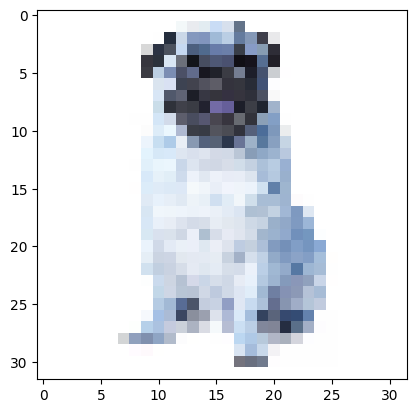

In [47]:
import matplotlib.pyplot as plt
plt.imshow(test_img)

In [43]:
test_input = test_img.reshape((1,32,32,3))

In [45]:
best_model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


array([[1.]], dtype=float32)